# AI Image Detection Robustness — End-to-End Analysis

**Research question:** How do JPEG compression, resizing, recompression, and combined social-media-style transformations affect AI-generated image detection, and can transformation-aware training improve robustness?

Labels: **0 = Real, 1 = AI-generated** (fixed everywhere). This notebook is a **read-only walkthrough**: it inspects saved, validated artifacts and never trains, re-runs inference, or modifies data. Implementation lives in `src/` and `scripts/`; numbers live in `results/`; narrative sources in `docs/`.

Sections mirror the completed study: dataset → baseline → robustness experiments (JPEG / resize / recompression / combined) → robust training → comparison → bias audit → visualization → conclusions.

In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent  # run from notebooks/ or repo root
assert (ROOT / "src").exists(), f"repo root not found from {Path.cwd()}"
R = ROOT / "results"
print("repo root:", ROOT)

repo root: C:\Data Science Bootcamp\Projects\ai-image-robustness


## 1. Dataset Overview and Split Verification

Tiny-GenImage subset, seed 42. Expected: 7,986 images; train 5,600 (2,800/2,800); val 1,200 (600/600); test 1,186 (600 Real / 586 AI). Fourteen test/AI files were unrecoverable from the source export and excluded without substitution; a SHA-256 audit found zero cross-split duplicates (decision record: `docs/RESULTS_REFERENCE.md`).

In [2]:
meta = json.load(open(R.parent / "data" / "splits" /
    "genimage_8000_split_v4" / "split_metadata.json"))
man = pd.read_csv(R.parent / "data" / "splits" /
    "genimage_8000_split_v4" / "manifest.csv")
assert len(man) == 7986 == meta["total_images"]
ct = man.groupby(["split", "label"]).size().unstack()
print(ct)
assert ct.loc["test", "real"] == 600 and ct.loc["test", "ai"] == 586
print("generators:", sorted(man[man.label == "ai"].generator.unique()))
print("SPLIT CHECKS PASSED")

label    ai  real
split            
test    586   600
train  2800  2800
val     600   600
generators: ['adm', 'biggan', 'glide', 'midjourney', 'sdv5', 'vqdm', 'wukong']
SPLIT CHECKS PASSED


## 2. Baseline Model Evaluation

EfficientNet-B0 (primary) and ResNet-50, clean-trained, threshold 0.5, evaluated once on the frozen test set (`scripts/verify_baseline.py`). EfficientNet-B0 was selected for its balanced recall/F1; ResNet-50 is more precise but misses more AI images.

In [3]:
for m in ("efficientnet_b0", "resnet50"):
    m_ = json.load(open(R / "metrics" / f"baseline_{m}_clean.json"))
    cm = m_["confusion_matrix"]
    assert sum(sum(r) for r in cm) == 1186
    print(f"{m}: acc={m_['accuracy']:.4f} prec={m_['precision']:.4f} "
          f"ai_rec={m_['ai_recall']:.4f} f1={m_['f1']:.4f} "
          f"auc={m_['roc_auc']:.4f} fnr={m_['ai_false_negative_rate']:.4f}")
print("Expected: effnet 0.9073/0.9034/0.9096/0.9065/0.9649/0.0904; "
      "resnet 0.9081/0.9409/0.8686/0.9033/0.9682/0.1314")

efficientnet_b0: acc=0.9073 prec=0.9034 ai_rec=0.9096 f1=0.9065 auc=0.9649 fnr=0.0904
resnet50: acc=0.9081 prec=0.9409 ai_rec=0.8686 f1=0.9033 auc=0.9682 fnr=0.1314
Expected: effnet 0.9073/0.9034/0.9096/0.9065/0.9649/0.0904; resnet 0.9081/0.9409/0.8686/0.9033/0.9682/0.1314


## 3. JPEG Compression Robustness (Experiment 1)

`scripts/run_jpeg_robustness.py` — clean + Q90/Q70/Q50/Q30 applied to both classes before preprocessing (1,186 images each). **Observation (not causal):** monotonic degradation concentrated in AI recall (90.96% → 55.46% at Q30) while precision holds ~0.88 — the detector misses AI images rather than false-alarming Real ones.

In [4]:
j = pd.read_csv(R / "metrics" / "jpeg_robustness_efficientnet_b0.csv")
assert len(j) == 5 and (j.n_samples == 1186).all()
print(j[["condition", "accuracy", "precision", "ai_recall", "ai_f1", "roc_auc", "ai_fnr"]].to_string(index=False))

condition  accuracy  precision  ai_recall    ai_f1  roc_auc   ai_fnr
    clean  0.907251   0.903390   0.909556 0.906463 0.964885 0.090444
 jpeg_q90  0.872681   0.887701   0.849829 0.868352 0.943151 0.150171
 jpeg_q70  0.827150   0.884848   0.747440 0.810361 0.906648 0.252560
 jpeg_q50  0.793423   0.876380   0.677474 0.764196 0.875547 0.322526
 jpeg_q30  0.742833   0.880759   0.554608 0.680628 0.844221 0.445392


## 4. Resizing Robustness (Experiment 2)

`scripts/run_resize_robustness.py` — scales 0.75/0.50/0.25 as true information loss (PIL downscale before the 224×224 preprocessing). **Observation:** the opposite failure mode from JPEG — Real precision collapses (false positives 57 → 494 at 0.25) while AI recall stays ~0.91–0.96; at 0.25 the model predicts nearly everything as AI.

In [5]:
r = pd.read_csv(R / "metrics" / "resize_robustness_efficientnet_b0.csv")
assert len(r) == 4 and (r.n_samples == 1186).all()
print(r[["condition", "accuracy", "precision", "ai_recall", "ai_f1", "roc_auc", "ai_fnr"]].to_string(index=False))

 condition  accuracy  precision  ai_recall    ai_f1  roc_auc   ai_fnr
     clean  0.907251   0.903390   0.909556 0.906463 0.964885 0.090444
resize_075  0.868465   0.812500   0.953925 0.877551 0.956025 0.046075
resize_050  0.770658   0.693827   0.959044 0.805158 0.927325 0.040956
resize_025  0.537099   0.518049   0.906143 0.659218 0.667976 0.093857


## 5. Recompression Robustness (Experiment 3)

`scripts/run_recompression_robustness.py` — two sequential same-quality passes (`apply_recompression`, distinct from single compression). **Observation:** tracks single JPEG almost exactly (Q90/Q70/Q30 identical to 4 decimals) — the second pass adds essentially no further damage.

In [6]:
c = pd.read_csv(R / "metrics" / "recompression_robustness_efficientnet_b0.csv")
assert len(c) == 5 and (c.n_samples == 1186).all()
print(c[["condition", "accuracy", "precision", "ai_recall", "ai_f1", "roc_auc", "ai_fnr"]].to_string(index=False))

    condition  accuracy  precision  ai_recall    ai_f1  roc_auc   ai_fnr
        clean  0.907251   0.903390   0.909556 0.906463 0.964885 0.090444
recomp_q90_p2  0.872681   0.889088   0.848123 0.868122 0.942806 0.151877
recomp_q70_p2  0.827150   0.887984   0.744027 0.809656 0.906206 0.255973
recomp_q50_p2  0.791737   0.877506   0.672355 0.761353 0.874966 0.327645
recomp_q30_p2  0.742833   0.882834   0.552901 0.679958 0.843884 0.447099


## 6. Combined Transformation Experiments (Experiment 4)

`scripts/run_combined_robustness.py` — C1 = Resize 50%→JPEG Q50, C2 = reverse, C3 = Resize→JPEG→JPEG (order preserved via `apply_pipeline`). **Observation:** order selects the failure mode — C1 fails like JPEG (AI recall 55.80%, Real side identical to clean), C2 like resize (Real precision collapse, AI recall 88.23%); the last transform dominates. C3 ≈ C1.

In [7]:
k = pd.read_csv(R / "metrics" / "combined_robustness_efficientnet_b0.csv")
assert len(k) == 4 and (k.n_samples == 1186).all()
print(k[["condition", "accuracy", "precision", "ai_recall", "ai_f1", "roc_auc", "ai_fnr"]].to_string(index=False))

          condition  accuracy  precision  ai_recall    ai_f1  roc_auc   ai_fnr
              clean  0.907251   0.903390   0.909556 0.906463 0.964885 0.090444
     c1_resize_jpeg  0.733558   0.851562   0.558020 0.674227 0.863815 0.441980
     c2_jpeg_resize  0.771501   0.719054   0.882253 0.792337 0.878387 0.117747
c3_resize_jpeg_jpeg  0.731029   0.856000   0.547782 0.668054 0.864797 0.452218


## 7. Robust Training Methodology (Experiment 5)

`scripts/train_robust.py` fine-tunes all EfficientNet-B0 parameters from the baseline checkpoint on TRAIN data only (seed 42; Adam 1e-4/1e-4, 10 epochs, batch 16, CUDA): per-image draw 40% clean / 20% JPEG Q{90,70,50,30} / 15% resize {0.75,0.50} / 15% recompression Q{90,70}×2 / 10% combined C1–C2. Unseen by policy: resize 0.25, recompression Q50/Q30, C3. Selection: best clean-validation accuracy (tie → lower val loss). Test data never touched. This cell only inspects the logged config — training is NOT re-run here.

In [8]:
cfg = json.load(open(ROOT / "models" / "robust" / "robust_training_config.json"))["config"]
hist = json.load(open(ROOT / "models" / "robust" / "robust_training_history.json"))
assert cfg["epochs"] == 10 and len(hist["val_acc"]) == 10
print("policy:", cfg["policy"])
print(f"best epoch={hist['best_epoch']} val_acc={hist['best_val_acc']:.4f} "
      "(expected: 8 / 0.9008)")

policy: {'clean': 0.4, 'jpeg': {'p': 0.2, 'qualities': [90, 70, 50, 30]}, 'resize': {'p': 0.15, 'scales': [0.75, 0.5]}, 'recompression': {'p': 0.15, 'qualities': [90, 70], 'passes': 2}, 'combined': {'p': 0.1, 'choices': ['C1', 'C2'], 'C1': 'resize(0.5)->jpeg(50)', 'C2': 'jpeg(50)->resize(0.5)'}, 'unseen_reserved': ['resize_0.25', 'recomp_q50', 'recomp_q30', 'C3']}
best epoch=8 val_acc=0.9008 (expected: 8 / 0.9008)


## 8. Baseline-versus-Robust Comparative Evaluation (Experiment 6)

`scripts/run_robust_evaluation.py` — both frozen checkpoints, same 1,186 images, 15 conditions, threshold 0.5 (30 model-condition rows). Deltas in percentage points (pp). **Observation:** JPEG-family AI recall largely preserved (Q30 +32.08pp, C3 +36.69pp) at a clean-accuracy cost of 1.77pp (90.73% → 88.95%); resize dips negligible; unseen conditions improve.

In [9]:
cmp = pd.read_csv(R / "metrics" / "baseline_vs_robust_efficientnet_b0.csv")
ev = pd.read_csv(R / "metrics" / "robust_evaluation_efficientnet_b0.csv")
assert len(cmp) == 15 and len(ev) == 30
assert ((ev.tn + ev.fp + ev.fn + ev.tp) == 1186).all()
print(cmp[["condition", "baseline_ai_recall", "robust_ai_recall", "delta_pp_ai_recall"]].to_string(index=False, formatters={
    "baseline_ai_recall": "{:.4f}".format, "robust_ai_recall": "{:.4f}".format,
    "delta_pp_ai_recall": "{:+.2f}".format}))

          condition baseline_ai_recall robust_ai_recall delta_pp_ai_recall
              clean             0.9096           0.9198              +1.02
           jpeg_q90             0.8498           0.9113              +6.14
           jpeg_q70             0.7474           0.8976             +15.02
           jpeg_q50             0.6775           0.8908             +21.33
           jpeg_q30             0.5546           0.8754             +32.08
         resize_075             0.9539           0.9471              -0.68
         resize_050             0.9590           0.9505              -0.85
         resize_025             0.9061           0.9488              +4.27
      recomp_q90_p2             0.8481           0.9147              +6.66
      recomp_q70_p2             0.7440           0.8942             +15.02
      recomp_q50_p2             0.6724           0.8891             +21.67
      recomp_q30_p2             0.5529           0.8754             +32.25
     c1_resize_jpeg      

## 9. Dataset Bias and Image-Format Audit (Experiment 8 + 9)

`scripts/audit_dataset_bias.py` probed all 7,986 images (read-only). **Measured:** 100% Real = `.jpeg`/JPEG with quantization tables vs 100% AI = `.png`/PNG without; RGBA only in AI (~14%), grayscale-L only in Real (~1.4%); AI always square (128–1024px), Real variable rectangles; a 7-feature metadata classifier scores 1.0000 val/test. `scripts/run_format_diagnostic.py`: lossless PNG re-encoding changes zero predictions; JPEG Q95 costs baseline −2.39pp / robust −1.02pp AI recall. **Limits:** descriptive only — unproven that networks use the shortcut; normalization does not remove the bias; JPEG conclusions stay entangled with format bias.

In [10]:
b = pd.read_csv(R / "metrics" / "dataset_bias_audit.csv")
print(b[["split", "label", "n", "extensions", "formats", "modes", "n_quantized"]].to_string(index=False))
f = pd.read_csv(R / "metrics" / "format_diagnostic_efficientnet_b0.csv")
assert len(f) == 6
print(f[["model", "condition", "accuracy", "ai_recall", "ai_fnr"]].to_string(index=False))

split  label    n      extensions        formats                      modes  n_quantized
train      0 2800 {".jpeg": 2800} {"JPEG": 2800}     {"RGB": 2760, "L": 40}         2800
train      1 2800  {".png": 2800}  {"PNG": 2800} {"RGB": 2400, "RGBA": 400}            0
  val      0  600  {".jpeg": 600}  {"JPEG": 600}       {"RGB": 593, "L": 7}          600
  val      1  600   {".png": 600}   {"PNG": 600}   {"RGB": 516, "RGBA": 84}            0
 test      0  600  {".jpeg": 600}  {"JPEG": 600}      {"RGB": 587, "L": 13}          600
 test      1  586   {".png": 586}   {"PNG": 586}   {"RGB": 501, "RGBA": 85}            0
   model condition  accuracy  ai_recall   ai_fnr
baseline     clean  0.907251   0.909556 0.090444
baseline       png  0.907251   0.909556 0.090444
baseline  jpeg_q95  0.898820   0.885666 0.114334
  robust     clean  0.889545   0.919795 0.080205
  robust       png  0.889545   0.919795 0.080205
  robust  jpeg_q95  0.886172   0.909556 0.090444


## 10. Results Visualization and Interpretation (Experiment 7)

`scripts/plot_robustness_results.py` renders all figures from the saved CSVs (validated, never hardcoded). Key visuals embedded below; full set in `results/graphs/`. **Reading guide:** JPEG-family damage = AI misses preserved by robust training; resize damage = Real false alarms, similar for both models; order flips the failure mode.

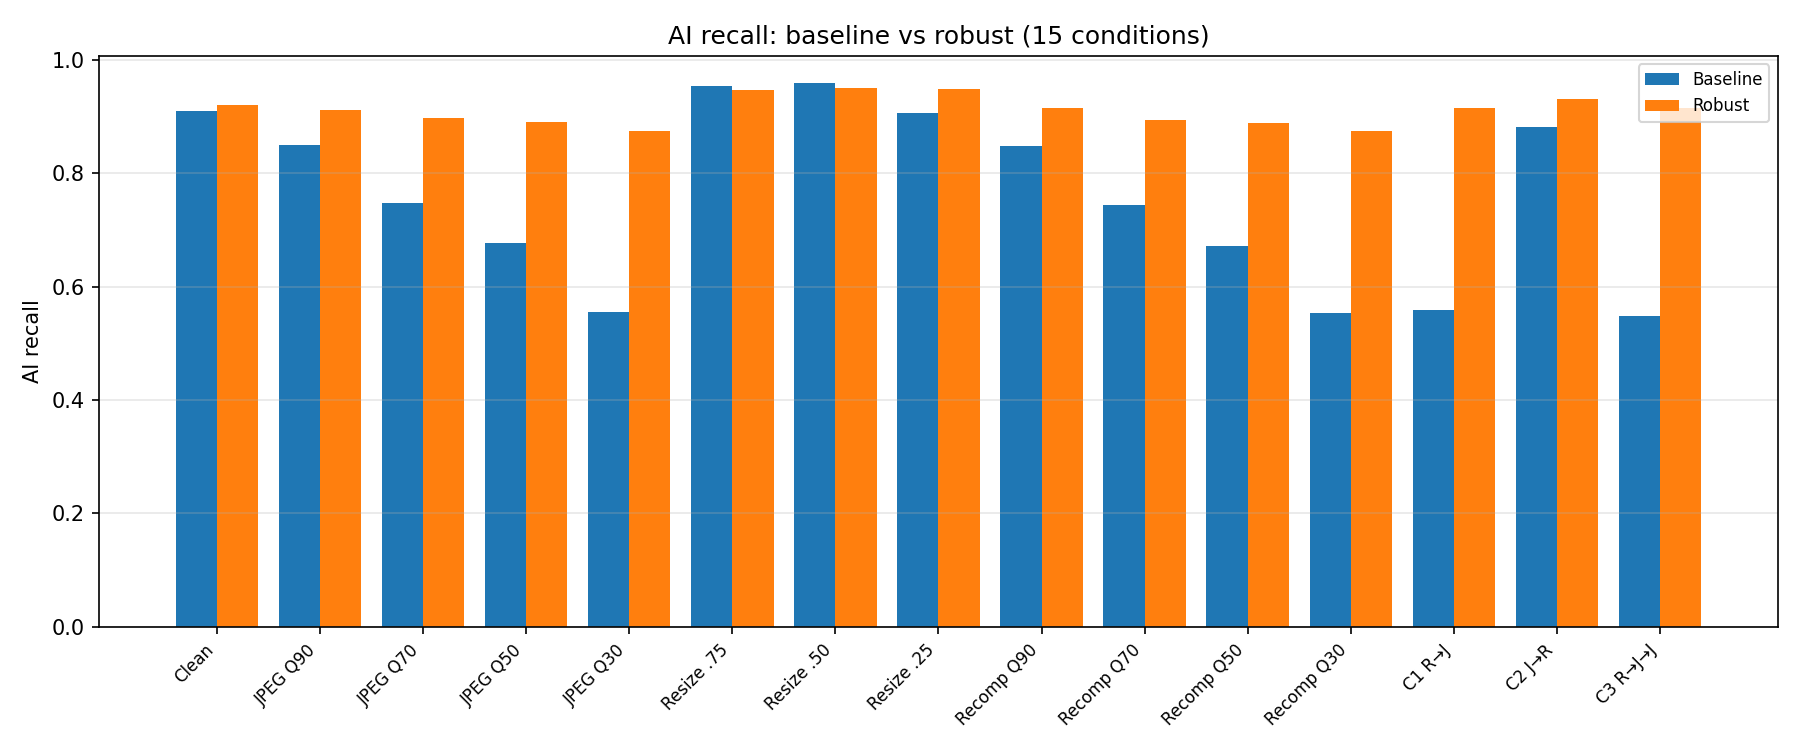

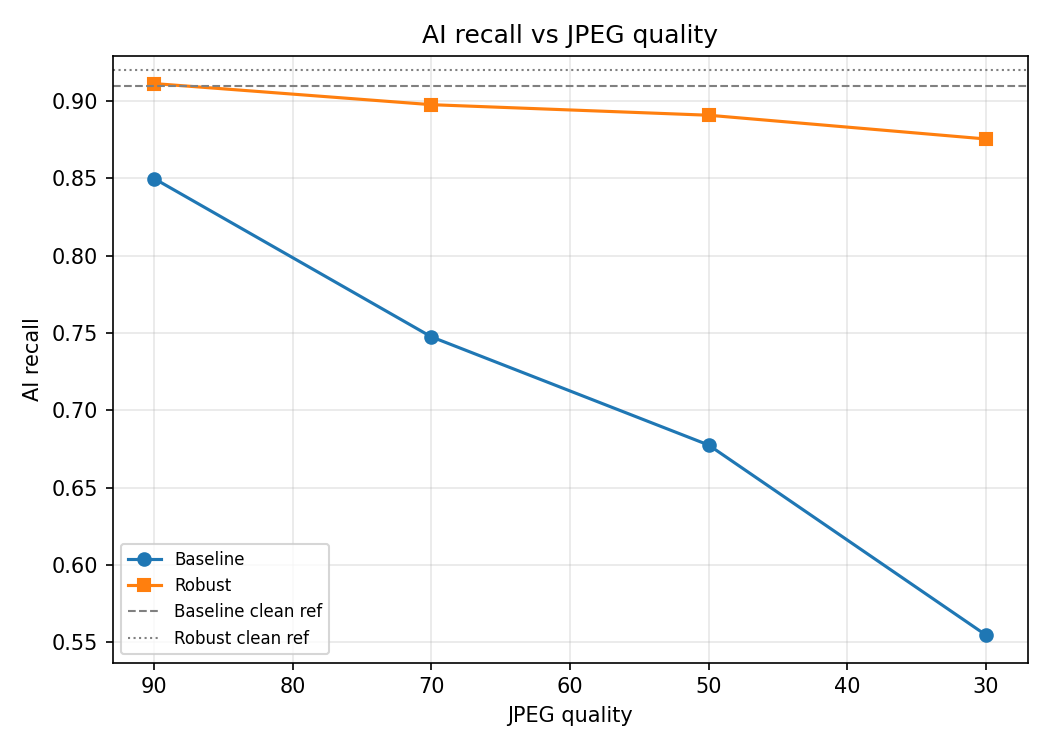

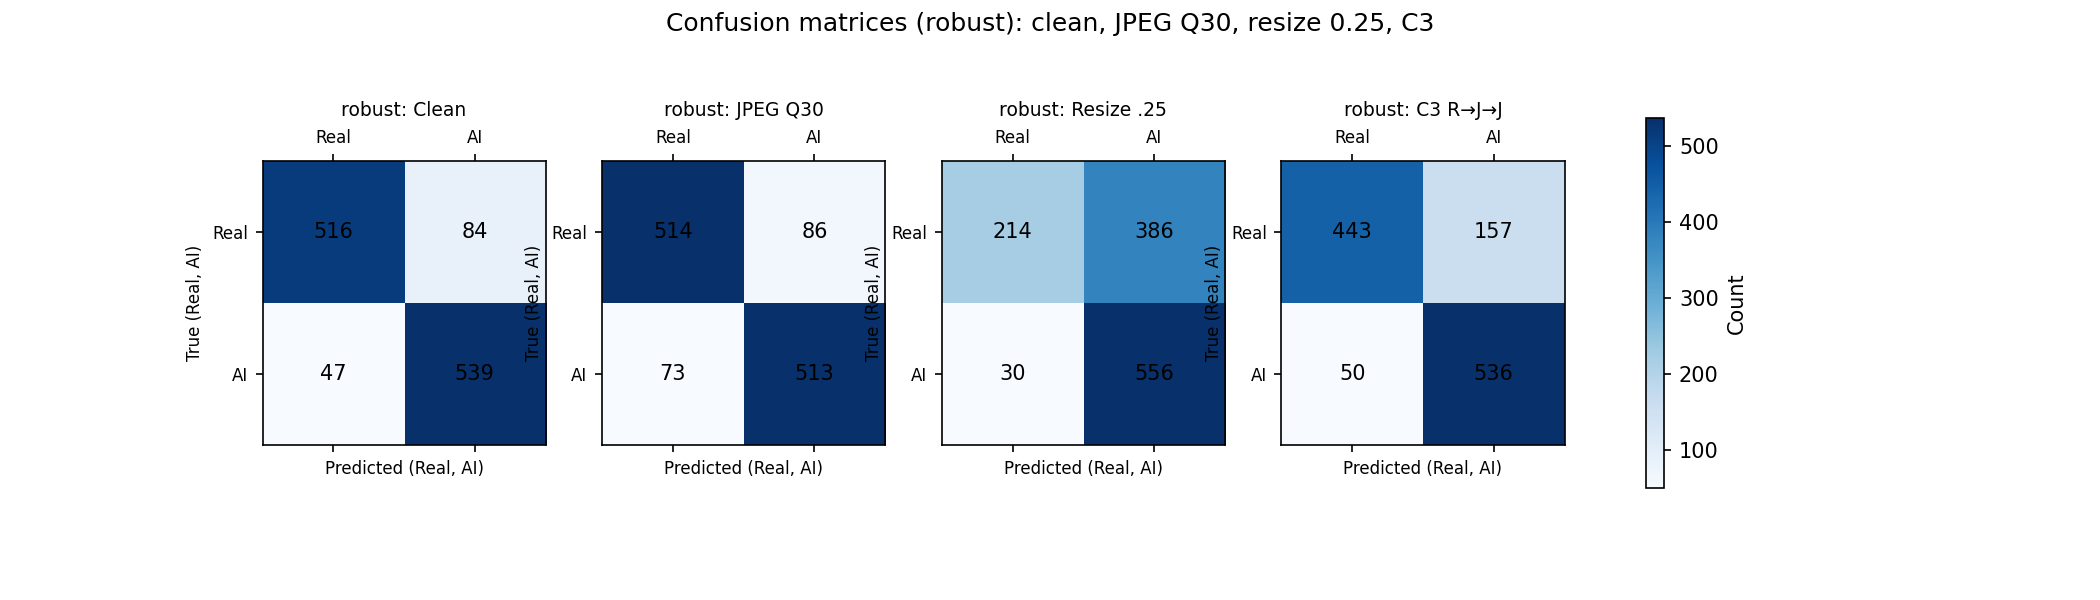

# Robustness Analysis Summary (generated from saved CSVs)

Source: `results/metrics/robust_evaluation_efficientnet_b0.csv` and
`results/metrics/baseline_vs_robust_efficientnet_b0.csv` (30 model-condition rows, n=1,186 each). Deltas are percentage points.

## Clean-performance trade-off (EfficientNet-B0, threshold 0.5)

- Baseline clean accuracy 0.9073 -> robust 0.8895 (-1.77 pp).
- Baseline clean AI recall 0.9096 -> robust 0.9198 (+1.02 pp); AI FNR 0.0904 -> 0.0802.
- Clean ROC-AUC 0.9649 -> 0.9591 (-0.58 pp).

## Largest AI-recall gains (robust minus baseline, pp)

- c3_resize_jpeg_jpeg: +36.69 pp.
- c1_resize_jpeg: +35.67 pp.
- recomp_q30_p2: +32.25 pp.
- jpeg_q30: +32.08 pp.
- recomp_q50_p2: +21.67 pp.

## Regressions / negligible change (AI recall delta < 0 pp)

- resize_050: -0.85 pp.
- resize_075: -0.68 pp.

## Unseen-by-training conditions (excluded from the training policy)

- resize_025: baseline AI recall 0.9061 -> robust 0.9488 (+4.27 pp).
- recomp_q50_p2: baseline AI recall

In [11]:
from IPython.display import Image, display
for f in ["ai_recall_all_conditions_baseline_vs_robust.png",
          "ai_recall_vs_jpeg_quality.png",
          "confusion_matrices_key_conditions_robust.png"]:
    p = R / "graphs" / f
    assert p.is_file(), f
    display(Image(filename=str(p)))
print(open(R / "metrics" / "robustness_analysis_summary.md").read())

## 11. Conclusions, Limitations, and Future Work

**Conclusions (within scope):** (1) JPEG/recompression collapse baseline AI recall; transformation-aware training restores it (≈+32pp at Q30, +36.69pp at C3) for −1.77pp clean accuracy. (2) Resizing instead destroys Real precision for both models. (3) Pipeline order selects the failure mode. (4) Held-out levels improve without having been trained on.

**Limitations:** single dataset/generators; one shared frozen test set; perfect format/geometry/mode shortcuts available to any model (unproven whether used); no significance testing; no external generalization; exact GPU bit-reproducibility not claimed. **No claim is made that this is a reliable general-purpose detector.**

**Future work:** significance tests, frequency-aware architectures, real platform pipelines, bias-mitigated data collection, broader generators.

In [12]:
print("Walkthrough complete — all cells read from validated artifacts only.")
print("See docs/FINAL_REPORT_SOURCE.md, docs/RESULTS_REFERENCE.md, and app/app.py.")

Walkthrough complete — all cells read from validated artifacts only.
See docs/FINAL_REPORT_SOURCE.md, docs/RESULTS_REFERENCE.md, and app/app.py.
